In [1]:
# This cell imports the main Python libraries we need.
# We use pandas and numpy for reading and organizing the EEG files.
# We use scipy for filtering and frequency analysis.
# We use matplotlib (plt) because plots are the easiest way to SEE differences
# between English and Native conditions instead of only looking at numbers.

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.stats import wilcoxon

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

In [2]:
# This cell stores the folder path and the meaning of your file names.
# This makes the rest of the notebook cleaner and easier to follow.

base_path = Path("/Users/mehdizaeifi/Desktop/5903_dataset")
results_path = base_path / "analysis_results"
results_path.mkdir(exist_ok=True)

channels = ["EEG1", "EEG2", "EEG3", "EEG4"]

topic_map = {
    1: "Probability",
    2: "Regression",
    3: "Heart function"
}

subject_native_map = {
    "111": "Persian",
    "112": "Hindi"
}

print("Dataset folder:", base_path)
print("Results folder:", results_path)

Dataset folder: /Users/mehdizaeifi/Desktop/5903_dataset
Results folder: /Users/mehdizaeifi/Desktop/5903_dataset/analysis_results


In [3]:
# This cell scans your dataset folder and reads information from each file name.
# It tells us subject, topic, and whether the file is English or Native.
# This is important because later we want to compare matched pairs:
# same subject + same topic + English vs Native.

pattern = re.compile(r"Sub(?P<subject>\d+)-(?P<topic>\d+)-(?P<lang>[EN])\.csv$", re.IGNORECASE)

rows = []

for file_path in sorted(base_path.glob("*.csv")):
    match = pattern.match(file_path.name)
    if match is None:
        print(f"Skipped file with unexpected name: {file_path.name}")
        continue

    subject = match.group("subject")
    topic_num = int(match.group("topic"))
    lang_code = match.group("lang").upper()

    condition = "English" if lang_code == "E" else "Native"
    actual_language = "English" if lang_code == "E" else subject_native_map.get(subject, "Unknown")

    rows.append({
        "file_id": file_path.stem,
        "file_name": file_path.name,
        "path": file_path,
        "subject": subject,
        "topic_num": topic_num,
        "topic_name": topic_map.get(topic_num, f"Topic {topic_num}"),
        "lang_code": lang_code,
        "condition": condition,
        "actual_language": actual_language
    })

file_table = pd.DataFrame(rows).sort_values(["subject", "topic_num", "condition"]).reset_index(drop=True)
file_table

,file_id,file_name,path,subject,topic_num,topic_name,lang_code,condition,actual_language
0,Sub111-1-E,Sub111-1-E.csv,/Users/mehdizaeifi/Desktop/5903_dataset/Sub111...,111,1,Probability,E,English,English
1,Sub111-1-N,Sub111-1-N.csv,/Users/mehdizaeifi/Desktop/5903_dataset/Sub111...,111,1,Probability,N,Native,Persian
2,Sub111-2-E,Sub111-2-E.csv,/Users/mehdizaeifi/Desktop/5903_dataset/Sub111...,111,2,Regression,E,English,English
3,Sub111-2-N,Sub111-2-N.csv,/Users/mehdizaeifi/Desktop/5903_dataset/Sub111...,111,2,Regression,N,Native,Persian
4,Sub111-3-E,Sub111-3-E.csv,/Users/mehdizaeifi/Desktop/5903_dataset/Sub111...,111,3,Heart function,E,English,English
5,Sub111-3-N,Sub111-3-N.csv,/Users/mehdizaeifi/Desktop/5903_dataset/Sub111...,111,3,Heart function,N,Native,Persian
6,Sub112-1-E,Sub112-1-E.csv,/Users/mehdizaeifi/Desktop/5903_dataset/Sub112...,112,1,Probability,E,English,English
7,Sub112-1-N,Sub112-1-N.csv,/Users/mehdizaeifi/Desktop/5903_dataset/Sub112...,112,1,Probability,N,Native,Hindi
8,Sub112-2-E,Sub112-2-E.csv,/Users/mehdizaeifi/Desktop/5903_dataset/Sub112...,112,2,Regression,E,English,English
9,Sub112-2-N,Sub112-2-N.csv,/Users/mehdizaeifi/Desktop/5903_dataset/Sub112...,112,2,Regression,N,Native,Hindi


In [6]:
# This cell loads each CSV file into memory.
# It also cleans the column names first, because sometimes CSV files have
# hidden spaces or special characters like BOM at the start of the first column.
# This helps avoid errors like "missing EEG1" when the column is really there.

recordings = {}
summary_rows = []

for row in file_table.itertuples(index=False):
    df = pd.read_csv(row.path)

    # Clean column names:
    # - convert to string
    # - remove leading/trailing spaces
    # - remove hidden BOM character
    df.columns = [str(c).strip().replace("\ufeff", "") for c in df.columns]

    # Optional: print columns for debugging
    print(f"{row.file_name} -> {df.columns.tolist()}")

    needed = {"relative_sec", "EEG1", "EEG2", "EEG3", "EEG4"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{row.file_name} is missing columns after cleaning: {missing}")

    df = df[["relative_sec", "EEG1", "EEG2", "EEG3", "EEG4"]].copy()
    df = df.sort_values("relative_sec").reset_index(drop=True)

    time_values = df["relative_sec"].to_numpy()
    dt = np.median(np.diff(time_values))
    fs = 1.0 / dt
    duration_sec = time_values[-1] - time_values[0]
    n_samples = len(df)

    recordings[row.file_id] = {
        "meta": row._asdict(),
        "raw": df,
        "fs": fs,
        "duration_sec": duration_sec
    }

    summary_rows.append({
        "file_id": row.file_id,
        "subject": row.subject,
        "topic_name": row.topic_name,
        "condition": row.condition,
        "actual_language": row.actual_language,
        "n_samples": n_samples,
        "duration_sec": duration_sec,
        "fs_estimated": fs,
        "missing_values": int(df.isna().sum().sum())
    })

recording_summary = pd.DataFrame(summary_rows)
recording_summary

Sub111-1-E.csv -> ['relative_sec', 'EEG1', 'EEG2', 'EEG3', 'EEG4']
Sub111-1-N.csv -> ['relative_sec', 'EEG1', 'EEG2', 'EEG3', 'EEG4']
Sub111-2-E.csv -> ['relative_sec', 'EEG2', 'EEG3', 'EEG4', 'EEG1']
Sub111-2-N.csv -> ['relative_sec', 'EEG1', 'EEG2', 'EEG3', 'EEG4']
Sub111-3-E.csv -> ['relative_sec', 'EEG1', 'EEG2', 'EEG3', 'EEG4']
Sub111-3-N.csv -> ['relative_sec', 'EEG1', 'EEG2', 'EEG3', 'EEG4']
Sub112-1-E.csv -> ['relative_sec', 'EEG1', 'EEG2', 'EEG3', 'EEG4']
Sub112-1-N.csv -> ['relative_sec', 'EEG1', 'EEG2', 'EEG3', 'EEG4']
Sub112-2-E.csv -> ['relative_sec', 'EEG1', 'EEG2', 'EEG3', 'EEG4']
Sub112-2-N.csv -> ['relative_sec', 'EEG1', 'EEG2', 'EEG3', 'EEG4']
Sub112-3-E.csv -> ['relative_sec', 'EEG1', 'EEG2', 'EEG3', 'EEG4']
Sub112-3-N.csv -> ['relative_sec', 'EEG1', 'EEG2', 'EEG3', 'EEG4']


,file_id,subject,topic_name,condition,actual_language,n_samples,duration_sec,fs_estimated,missing_values
0,Sub111-1-E,111,Probability,English,English,23790,118.945,200.0,0
1,Sub111-1-N,111,Probability,Native,Persian,23692,118.455,200.0,0
2,Sub111-2-E,111,Regression,English,English,23802,119.005,200.0,0
3,Sub111-2-N,111,Regression,Native,Persian,23724,118.615,200.0,0
4,Sub111-3-E,111,Heart function,English,English,23877,119.380,200.0,0
5,Sub111-3-N,111,Heart function,Native,Persian,23844,119.215,200.0,0
6,Sub112-1-E,112,Probability,English,English,23717,118.580,200.0,0
7,Sub112-1-N,112,Probability,Native,Hindi,23735,118.670,200.0,0
8,Sub112-2-E,112,Regression,English,English,23788,118.935,200.0,0
9,Sub112-2-N,112,Regression,Native,Hindi,23666,118.325,200.0,0


In [7]:
# This cell gives a simple quality overview.
# It is a good first check before doing deeper EEG analysis.
# If a file has many missing values, wrong duration, or strange sampling rate,
# we can catch that problem early.

print(recording_summary[["file_id", "subject", "topic_name", "condition", "duration_sec", "fs_estimated", "missing_values"]])

print("\nMean recording duration (sec):", recording_summary["duration_sec"].mean())
print("Mean estimated sampling rate (Hz):", recording_summary["fs_estimated"].mean())

       file_id subject      topic_name condition  duration_sec  fs_estimated  \
0   Sub111-1-E     111     Probability   English       118.945         200.0   
1   Sub111-1-N     111     Probability    Native       118.455         200.0   
2   Sub111-2-E     111      Regression   English       119.005         200.0   
3   Sub111-2-N     111      Regression    Native       118.615         200.0   
4   Sub111-3-E     111  Heart function   English       119.380         200.0   
5   Sub111-3-N     111  Heart function    Native       119.215         200.0   
6   Sub112-1-E     112     Probability   English       118.580         200.0   
7   Sub112-1-N     112     Probability    Native       118.670         200.0   
8   Sub112-2-E     112      Regression   English       118.935         200.0   
9   Sub112-2-N     112      Regression    Native       118.325         200.0   
10  Sub112-3-E     112  Heart function   English       119.250         200.0   
11  Sub112-3-N     112  Heart function  

In [8]:
# This cell defines the main EEG cleaning steps.
# We remove the large DC offset, apply a notch filter for 60 Hz noise,
# and use a bandpass filter to keep the EEG range we care about.
# This gives cleaner signals for plots and power analysis.

def notch_filter(x, fs, freq=60.0, q=30.0):
    if freq >= fs / 2:
        return x
    b, a = signal.iirnotch(w0=freq, Q=q, fs=fs)
    return signal.filtfilt(b, a, x)

def bandpass_filter(x, fs, low=1.0, high=40.0, order=4):
    nyq = fs / 2.0
    high = min(high, nyq * 0.95)
    low = max(low, 0.1)
    b, a = signal.butter(order, [low / nyq, high / nyq], btype="band")
    return signal.filtfilt(b, a, x)

def preprocess_recording(df, fs, channel_names):
    clean_df = pd.DataFrame()
    clean_df["relative_sec"] = df["relative_sec"].values

    for ch in channel_names:
        x = df[ch].astype(float).to_numpy()

        # Fill missing values if any
        if np.isnan(x).any():
            x = pd.Series(x).interpolate(limit_direction="both").to_numpy()

        # Remove constant offset
        x = signal.detrend(x, type="constant")

        # Remove 60 Hz line noise
        x = notch_filter(x, fs)

        # Keep EEG frequency range
        x = bandpass_filter(x, fs, low=1.0, high=40.0)

        clean_df[ch] = x

    return clean_df

def zscore_recording(df, channel_names):
    z_df = pd.DataFrame()
    z_df["relative_sec"] = df["relative_sec"].values

    for ch in channel_names:
        x = df[ch].to_numpy()
        std = np.std(x)
        if std == 0:
            z_df[ch] = np.zeros_like(x)
        else:
            z_df[ch] = (x - np.mean(x)) / std

    return z_df

In [9]:
# This cell runs the preprocessing on every file.
# We also create z-scored versions, because z-scored plots are easier to compare
# across channels and across conditions.

for file_id, item in recordings.items():
    raw_df = item["raw"]
    fs = item["fs"]

    clean_df = preprocess_recording(raw_df, fs, channels)
    z_df = zscore_recording(clean_df, channels)

    recordings[file_id]["clean"] = clean_df
    recordings[file_id]["z"] = z_df

print("Finished preprocessing all recordings.")

Finished preprocessing all recordings.


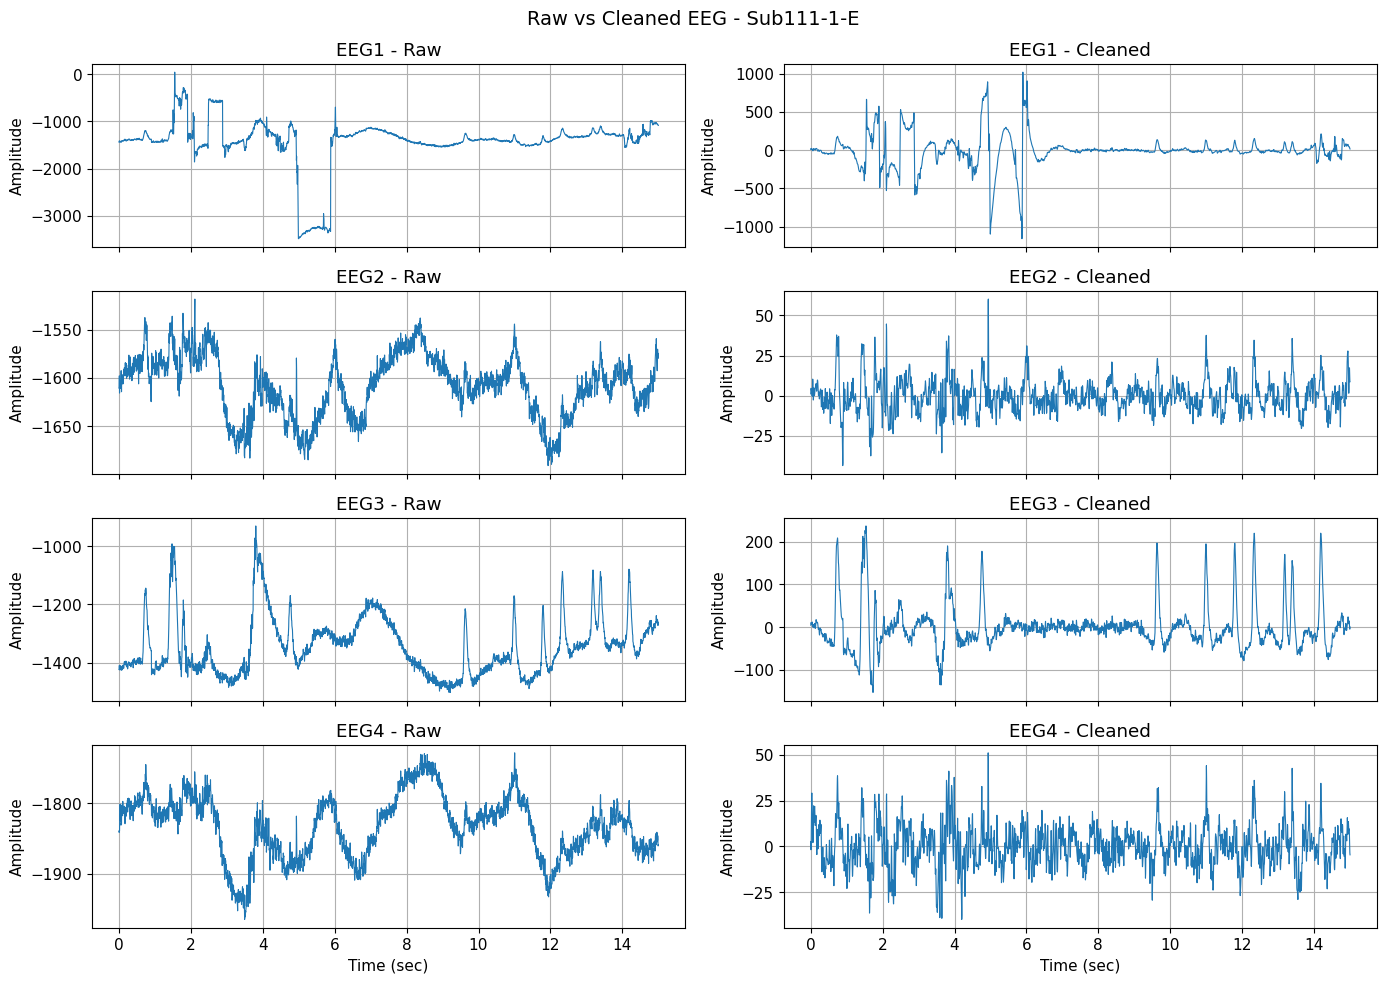

In [10]:
# This cell shows one example recording before and after preprocessing.
# It helps you explain in your project that the raw EEG had offset and noise,
# and that you cleaned it before doing any comparison.
# We use plt here because the before/after picture is much clearer than just saying it in words.

example_file = file_table.iloc[0]["file_id"]   # change this if you want
seconds_to_show = 15

raw_df = recordings[example_file]["raw"]
clean_df = recordings[example_file]["clean"]

mask = raw_df["relative_sec"] <= seconds_to_show

fig, axes = plt.subplots(len(channels), 2, figsize=(14, 10), sharex=True)
fig.suptitle(f"Raw vs Cleaned EEG - {example_file}", fontsize=14)

for i, ch in enumerate(channels):
    axes[i, 0].plot(raw_df.loc[mask, "relative_sec"], raw_df.loc[mask, ch], linewidth=0.8)
    axes[i, 0].set_title(f"{ch} - Raw")
    axes[i, 0].set_ylabel("Amplitude")

    axes[i, 1].plot(clean_df.loc[mask, "relative_sec"], clean_df.loc[mask, ch], linewidth=0.8)
    axes[i, 1].set_title(f"{ch} - Cleaned")
    axes[i, 1].set_ylabel("Amplitude")

axes[-1, 0].set_xlabel("Time (sec)")
axes[-1, 1].set_xlabel("Time (sec)")
plt.tight_layout()
plt.show()

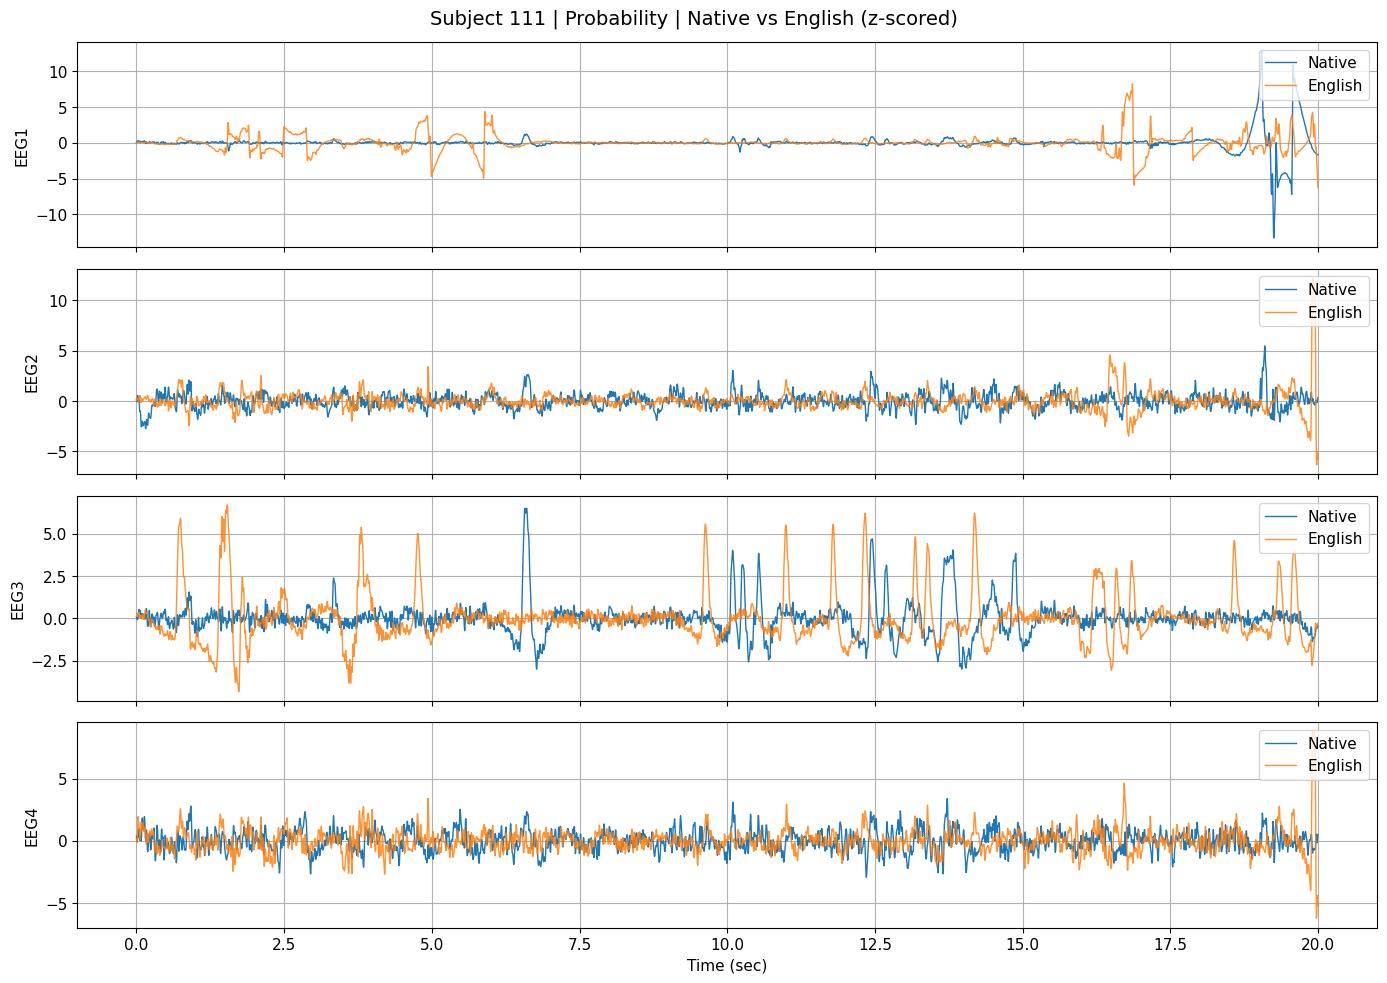

In [12]:
# This cell makes a direct side-by-side comparison for one subject and one topic.
# It is useful because our study question is exactly this:
# for the same person and same topic, does Native look different from English?
# We use z-scored signals so the shapes are easier to compare.

def get_pair_file_ids(subject, topic_num):
    pair = file_table[(file_table["subject"] == str(subject)) & (file_table["topic_num"] == topic_num)]
    native_id = pair.loc[pair["condition"] == "Native", "file_id"].iloc[0]
    english_id = pair.loc[pair["condition"] == "English", "file_id"].iloc[0]
    return native_id, english_id

def plot_pair_time_series(subject, topic_num, seconds=20):
    native_id, english_id = get_pair_file_ids(subject, topic_num)

    native_df = recordings[native_id]["z"]
    english_df = recordings[english_id]["z"]

    mask_n = native_df["relative_sec"] <= seconds
    mask_e = english_df["relative_sec"] <= seconds

    fig, axes = plt.subplots(len(channels), 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Subject {subject} | {topic_map[topic_num]} | Native vs English (z-scored)", fontsize=14)

    for i, ch in enumerate(channels):
        axes[i].plot(native_df.loc[mask_n, "relative_sec"], native_df.loc[mask_n, ch], label="Native", linewidth=1.0)
        axes[i].plot(english_df.loc[mask_e, "relative_sec"], english_df.loc[mask_e, ch], label="English", linewidth=1.0, alpha=0.85)
        axes[i].set_ylabel(ch)
        axes[i].legend(loc="upper right")

    axes[-1].set_xlabel("Time (sec)")
    plt.tight_layout()
    plt.show()

# Example
plot_pair_time_series(subject="111", topic_num=1, seconds=20)

Simple summary table:


,subject,topic_num,topic_name,condition,band,rel_power
0,111,1,Probability,English,alpha,0.061265
1,111,1,Probability,English,beta,0.085033
2,111,1,Probability,English,delta,0.658349
3,111,1,Probability,English,gamma,0.015032
4,111,1,Probability,English,theta,0.151117
5,111,1,Probability,Native,alpha,0.044736
6,111,1,Probability,Native,beta,0.097312
7,111,1,Probability,Native,delta,0.674528
8,111,1,Probability,Native,gamma,0.031280
9,111,1,Probability,Native,theta,0.123805


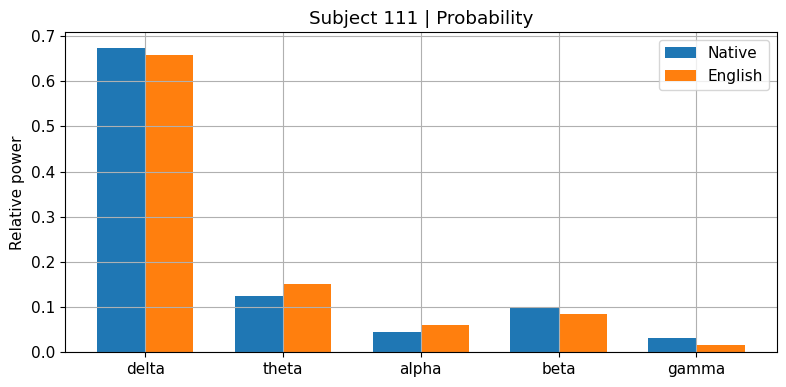

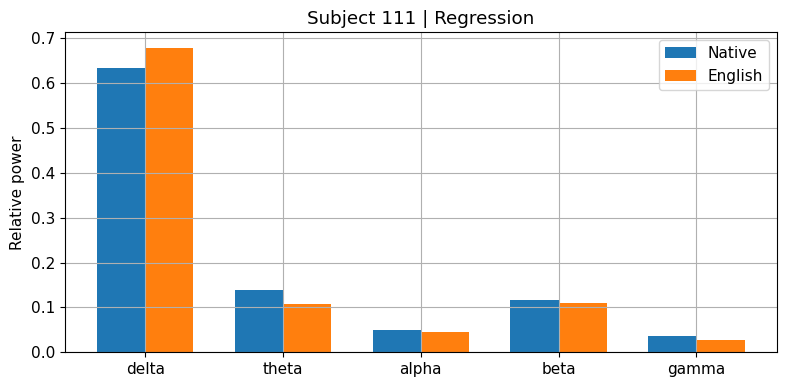

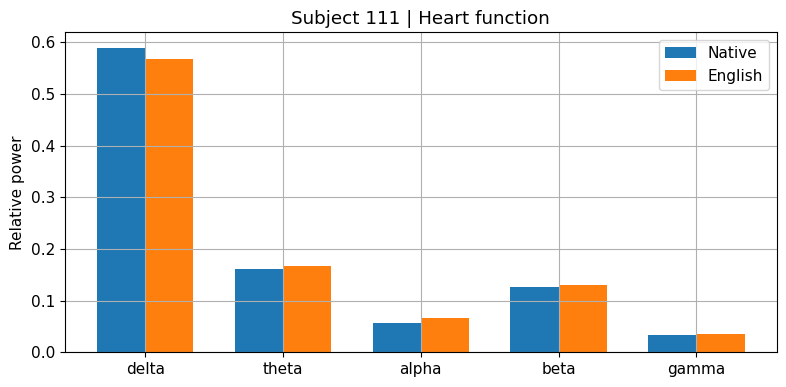

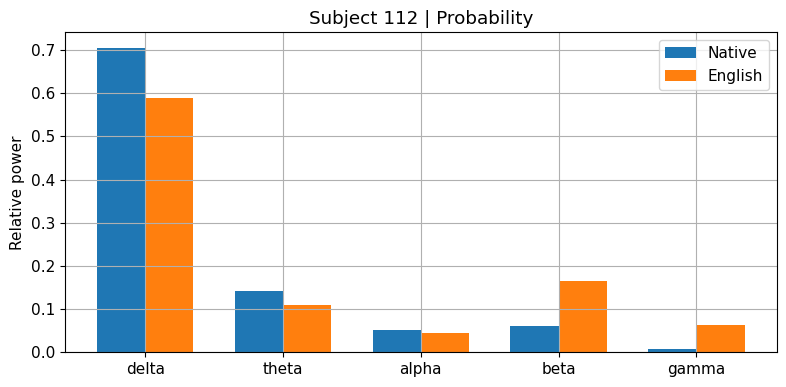

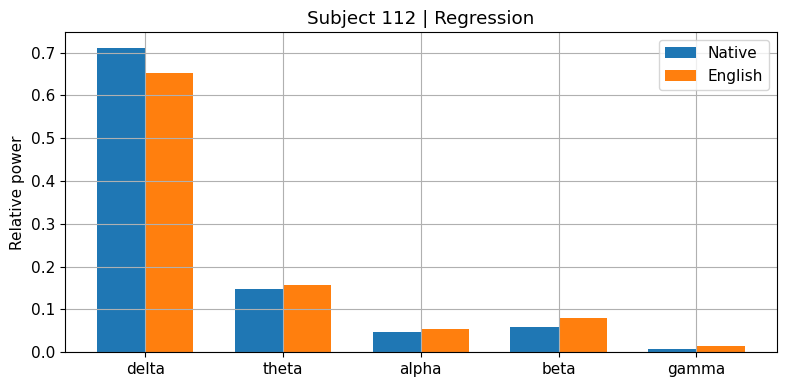

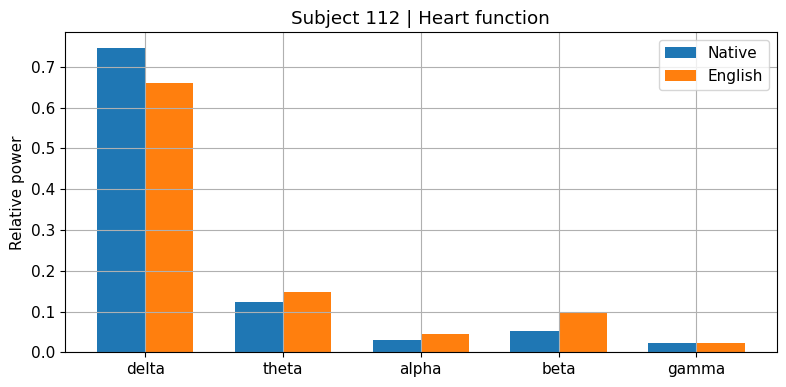

In [22]:
# This cell computes simple EEG band-power results for all files.
# It gives one average value across the 4 channels, so the result is easier to read.
# Then it shows Native vs English bar plots for every subject and every topic.

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
    "gamma": (30, 40)
}

def bandpower_from_psd(freqs, psd, low, high):
    mask = (freqs >= low) & (freqs <= high)
    if mask.sum() < 2:
        return np.nan
    return np.trapezoid(psd[mask], freqs[mask])

rows = []

for file_id, item in recordings.items():
    meta = item["meta"]
    df = item["clean"]
    fs = item["fs"]

    for ch in channels:
        x = df[ch].to_numpy()
        freqs, psd = compute_psd(x, fs)

        total_power = bandpower_from_psd(freqs, psd, 1, 40)

        for band_name, (low, high) in bands.items():
            bp = bandpower_from_psd(freqs, psd, low, high)
            rel_bp = bp / total_power if total_power > 0 else np.nan

            rows.append({
                "subject": str(meta["subject"]),
                "topic_num": int(meta["topic_num"]),
                "topic_name": meta["topic_name"],
                "condition": meta["condition"],
                "channel": ch,
                "band": band_name,
                "rel_power": rel_bp
            })

bandpower_table = pd.DataFrame(rows)

# Average across the 4 channels
bandpower_summary = (
    bandpower_table
    .groupby(["subject", "topic_num", "topic_name", "condition", "band"], as_index=False)["rel_power"]
    .mean()
)

print("Simple summary table:")
display(bandpower_summary)

# Plot all subject-topic comparisons
for subject in sorted(bandpower_summary["subject"].unique(), key=int):
    for topic_num in sorted(bandpower_summary["topic_num"].unique()):
        temp = bandpower_summary[
            (bandpower_summary["subject"] == subject) &
            (bandpower_summary["topic_num"] == topic_num)
        ]

        native_vals = temp[temp["condition"] == "Native"].set_index("band")["rel_power"]
        english_vals = temp[temp["condition"] == "English"].set_index("band")["rel_power"]

        band_order = list(bands.keys())
        x = np.arange(len(band_order))
        width = 0.35

        plt.figure(figsize=(8, 4))
        plt.bar(x - width/2, [native_vals.get(b, np.nan) for b in band_order], width=width, label="Native")
        plt.bar(x + width/2, [english_vals.get(b, np.nan) for b in band_order], width=width, label="English")
        plt.xticks(x, band_order)
        plt.ylabel("Relative power")
        plt.title(f"Subject {subject} | {topic_map[topic_num]}")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [25]:
# This cell averages band power across the 4 channels.
# It uses the simpler bandpower_table from the new Cell 11.
# Since the simple version only keeps rel_power, we average only rel_power.

bandpower_summary = (
    bandpower_table
    .groupby(["subject", "topic_num", "topic_name", "condition", "band"], as_index=False)["rel_power"]
    .mean()
)

bandpower_summary

,subject,topic_num,topic_name,condition,band,rel_power
0,111,1,Probability,English,alpha,0.061265
1,111,1,Probability,English,beta,0.085033
2,111,1,Probability,English,delta,0.658349
3,111,1,Probability,English,gamma,0.015032
4,111,1,Probability,English,theta,0.151117
5,111,1,Probability,Native,alpha,0.044736
6,111,1,Probability,Native,beta,0.097312
7,111,1,Probability,Native,delta,0.674528
8,111,1,Probability,Native,gamma,0.031280
9,111,1,Probability,Native,theta,0.123805


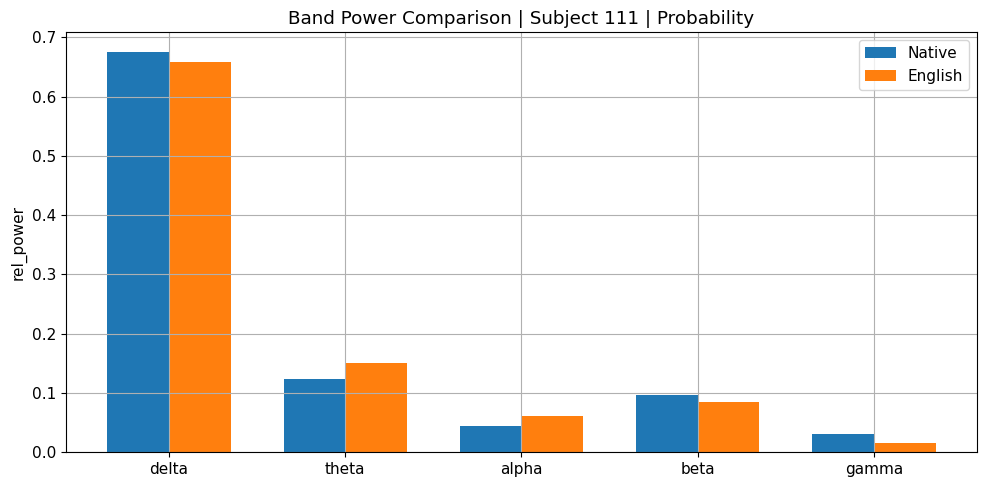

In [26]:
# This cell creates one of the most useful final comparison plots in your project.
# It shows, for one matched pair, whether Native and English differ in delta/theta/alpha/beta/gamma.
# Relative power is often easier to compare than absolute power.

def plot_bandpower_bars(subject, topic_num, value_col="rel_power"):
    temp = bandpower_summary[
        (bandpower_summary["subject"] == str(subject)) &
        (bandpower_summary["topic_num"] == topic_num)
    ].copy()

    native_vals = temp[temp["condition"] == "Native"].set_index("band")[value_col]
    english_vals = temp[temp["condition"] == "English"].set_index("band")[value_col]

    band_order = list(bands.keys())
    x = np.arange(len(band_order))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, [native_vals[b] for b in band_order], width=width, label="Native")
    plt.bar(x + width/2, [english_vals[b] for b in band_order], width=width, label="English")
    plt.xticks(x, band_order)
    plt.ylabel(value_col)
    plt.title(f"Band Power Comparison | Subject {subject} | {topic_map[topic_num]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example
plot_bandpower_bars(subject="111", topic_num=1, value_col="rel_power")

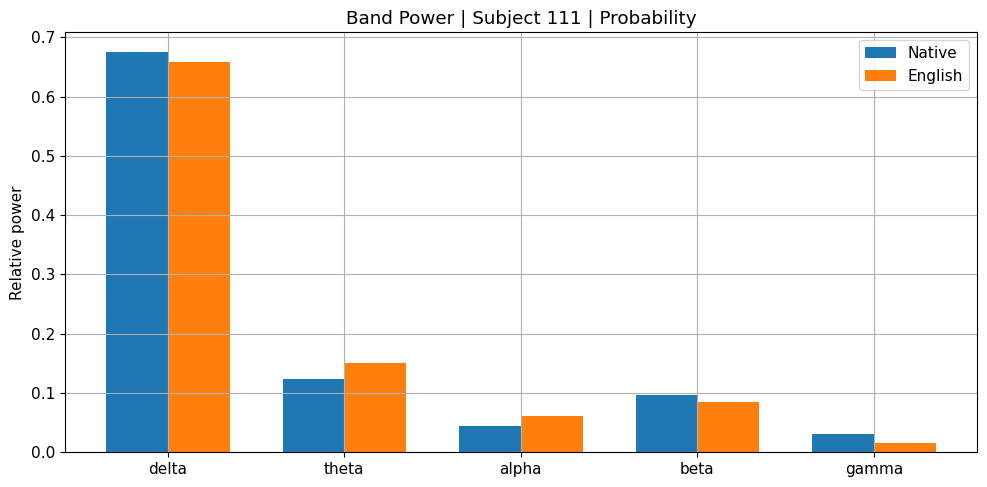

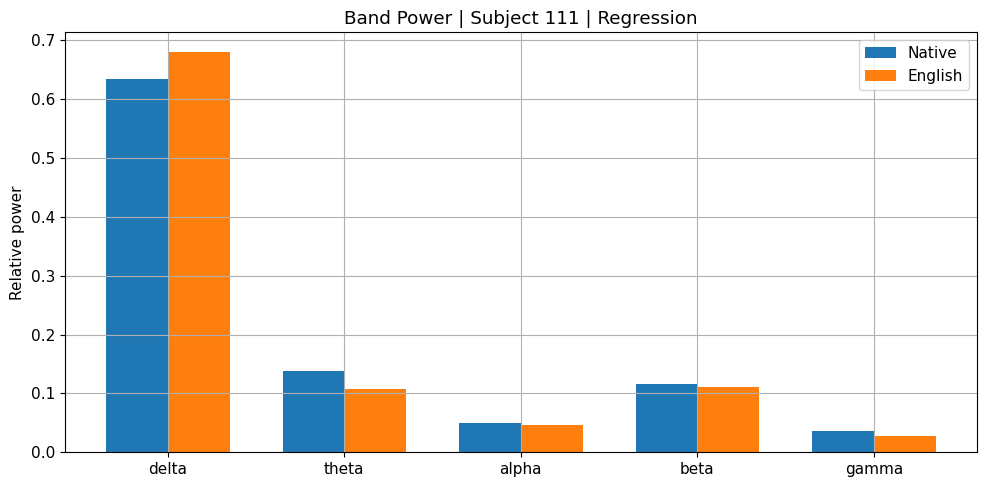

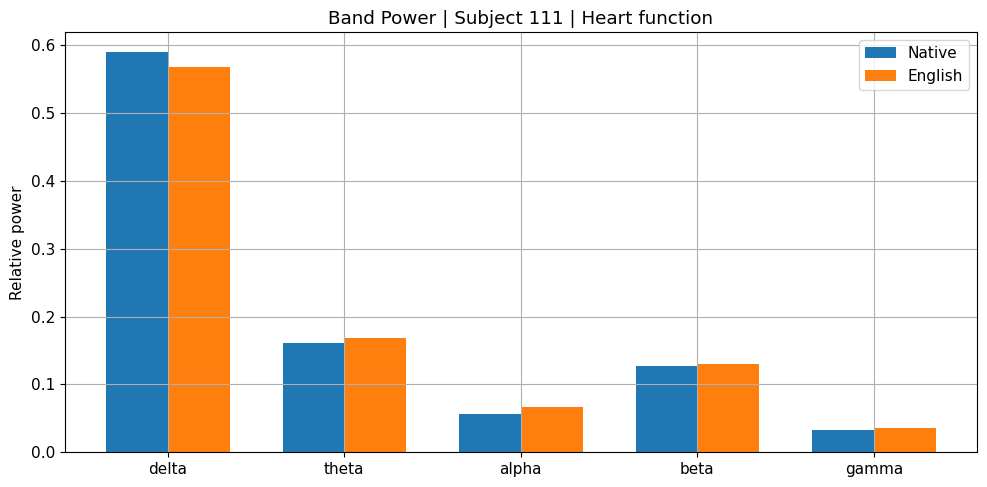

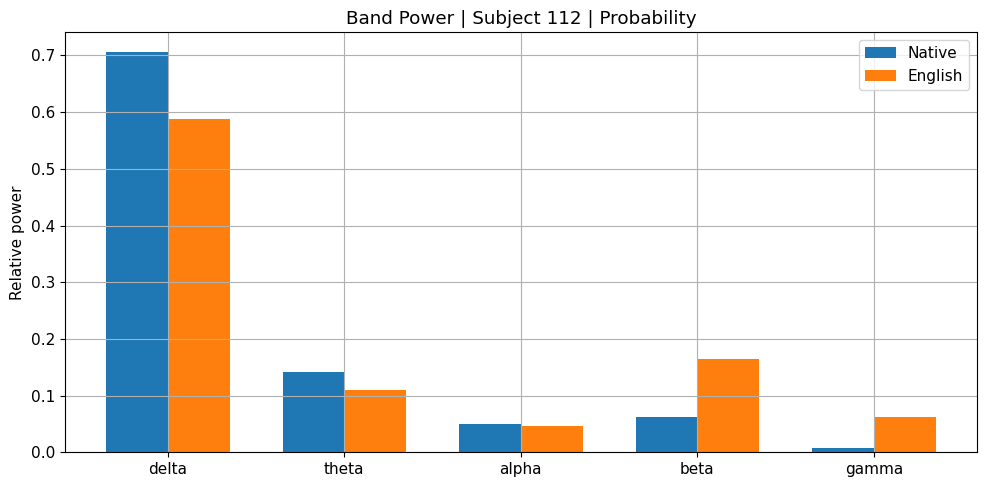

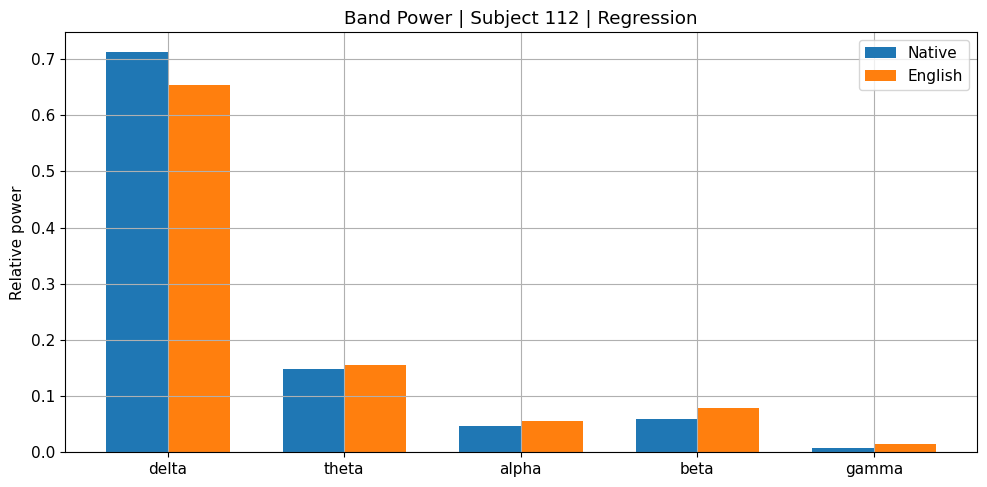

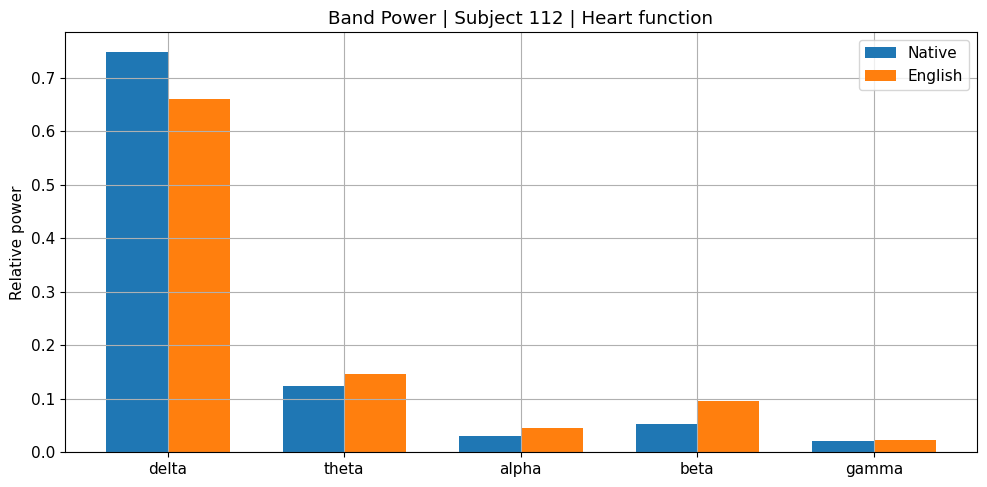

In [27]:
# This cell automatically makes the same band-power plot for every subject and every topic.
# This saves time and gives you a complete set of figures for your project.

for subject in sorted(file_table["subject"].unique()):
    for topic_num in sorted(file_table["topic_num"].unique()):
        temp = bandpower_summary[
            (bandpower_summary["subject"] == subject) &
            (bandpower_summary["topic_num"] == topic_num)
        ].copy()

        native_vals = temp[temp["condition"] == "Native"].set_index("band")["rel_power"]
        english_vals = temp[temp["condition"] == "English"].set_index("band")["rel_power"]

        band_order = list(bands.keys())
        x = np.arange(len(band_order))
        width = 0.35

        plt.figure(figsize=(10, 5))
        plt.bar(x - width/2, [native_vals[b] for b in band_order], width=width, label="Native")
        plt.bar(x + width/2, [english_vals[b] for b in band_order], width=width, label="English")
        plt.xticks(x, band_order)
        plt.ylabel("Relative power")
        plt.title(f"Band Power | Subject {subject} | {topic_map[topic_num]}")
        plt.legend()
        plt.tight_layout()

        save_name = results_path / f"bandpower_Sub{subject}_Topic{topic_num}.png"
        plt.savefig(save_name, dpi=300, bbox_inches="tight")
        plt.show()

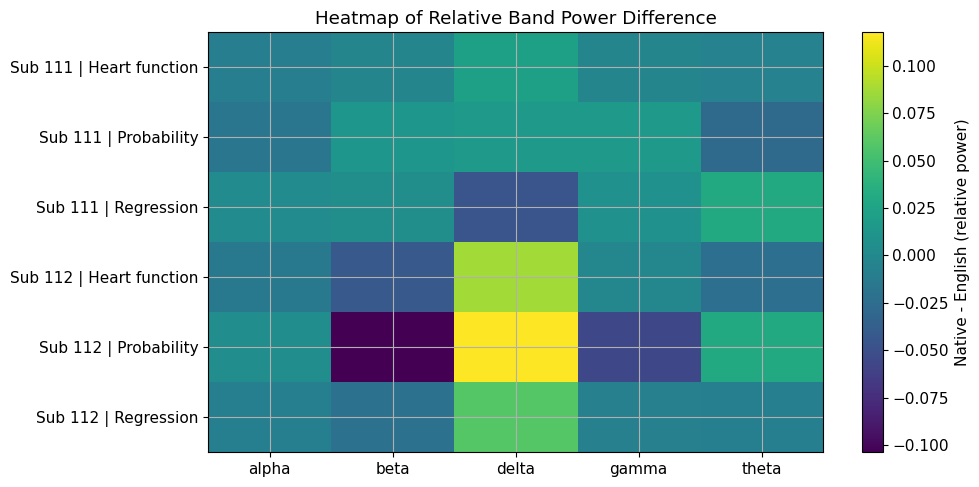

band                       alpha      beta     delta     gamma     theta
subject topic_name                                                      
111     Heart function -0.009459 -0.003226  0.022018 -0.003263 -0.006046
        Probability    -0.016528  0.012279  0.016178  0.016248 -0.027312
        Regression      0.003360  0.006006 -0.045678  0.008243  0.030381
112     Heart function -0.014572 -0.041991  0.087023 -0.001485 -0.023325
        Probability     0.005016 -0.103805  0.117596 -0.055567  0.030980
        Regression     -0.008529 -0.019965  0.058936 -0.007335 -0.008494

In [29]:
#15

# This cell summarizes the direction of the difference.
# Positive means Native > English.
# Negative means English > Native.
# This is a compact figure that helps you quickly see patterns across all topics.

heat_df = (
    bandpower_summary
    .pivot_table(index=["subject", "topic_name", "band"], columns="condition", values="rel_power")
    .reset_index()
)

heat_df["Native_minus_English"] = heat_df["Native"] - heat_df["English"]

heat_matrix = heat_df.pivot_table(
    index=["subject", "topic_name"],
    columns="band",
    values="Native_minus_English"
)

plt.figure(figsize=(10, 5))
im = plt.imshow(heat_matrix.values, aspect="auto")
plt.colorbar(im, label="Native - English (relative power)")
plt.xticks(np.arange(len(heat_matrix.columns)), heat_matrix.columns)
plt.yticks(np.arange(len(heat_matrix.index)), [f"Sub {s} | {t}" for s, t in heat_matrix.index])
plt.title("Heatmap of Relative Band Power Difference")
plt.tight_layout()
plt.show()

heat_matrix

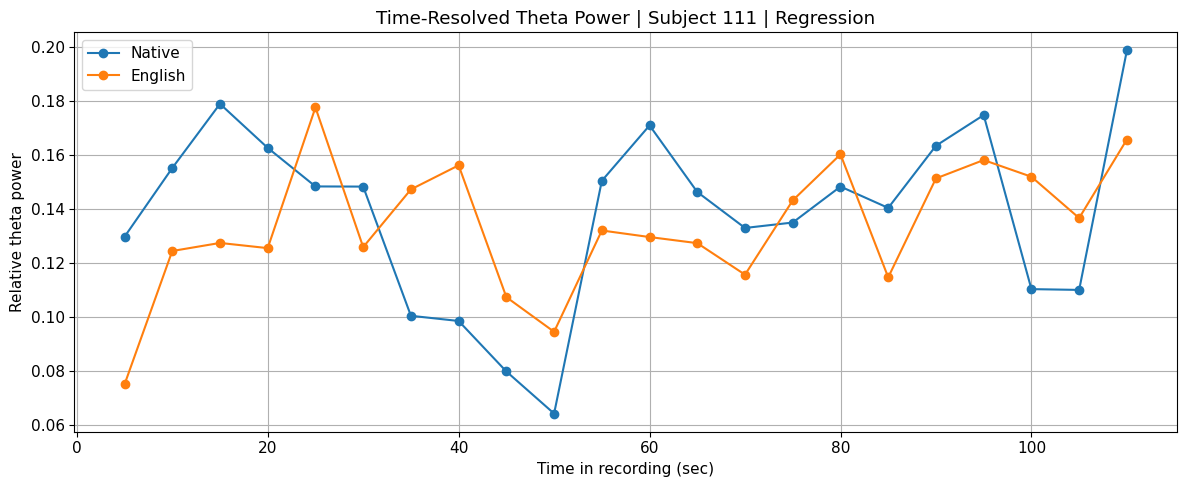

In [30]:
# This cell shows how band power changes over time during the video.
# This is helpful because sometimes the difference is not constant from start to end.
# For example, one language may show more effort early and then settle later.
# That kind of story can be very useful in your discussion section.

def rolling_bandpower(df, fs, window_sec=10, step_sec=5):
    window_n = int(window_sec * fs)
    step_n = int(step_sec * fs)

    rows = []

    for start in range(0, len(df) - window_n + 1, step_n):
        stop = start + window_n
        seg = df.iloc[start:stop]
        mid_time = seg["relative_sec"].mean()

        for ch in channels:
            freqs, psd = compute_psd(seg[ch].to_numpy(), fs)
            total_power = bandpower_from_psd(freqs, psd, 1, 40)

            for band_name, (low, high) in bands.items():
                bp = bandpower_from_psd(freqs, psd, low, high)
                rel_bp = bp / total_power if total_power > 0 else np.nan

                rows.append({
                    "mid_time_sec": mid_time,
                    "channel": ch,
                    "band": band_name,
                    "abs_power": bp,
                    "rel_power": rel_bp
                })

    return pd.DataFrame(rows)

def plot_time_resolved_band(subject, topic_num, band_name="theta"):
    native_id, english_id = get_pair_file_ids(subject, topic_num)

    native_roll = rolling_bandpower(recordings[native_id]["clean"], recordings[native_id]["fs"])
    english_roll = rolling_bandpower(recordings[english_id]["clean"], recordings[english_id]["fs"])

    native_mean = native_roll[native_roll["band"] == band_name].groupby("mid_time_sec")["rel_power"].mean()
    english_mean = english_roll[english_roll["band"] == band_name].groupby("mid_time_sec")["rel_power"].mean()

    plt.figure(figsize=(12, 5))
    plt.plot(native_mean.index, native_mean.values, marker="o", label="Native")
    plt.plot(english_mean.index, english_mean.values, marker="o", label="English")
    plt.xlabel("Time in recording (sec)")
    plt.ylabel(f"Relative {band_name} power")
    plt.title(f"Time-Resolved {band_name.capitalize()} Power | Subject {subject} | {topic_map[topic_num]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example
plot_time_resolved_band(subject="111", topic_num=2, band_name="theta")

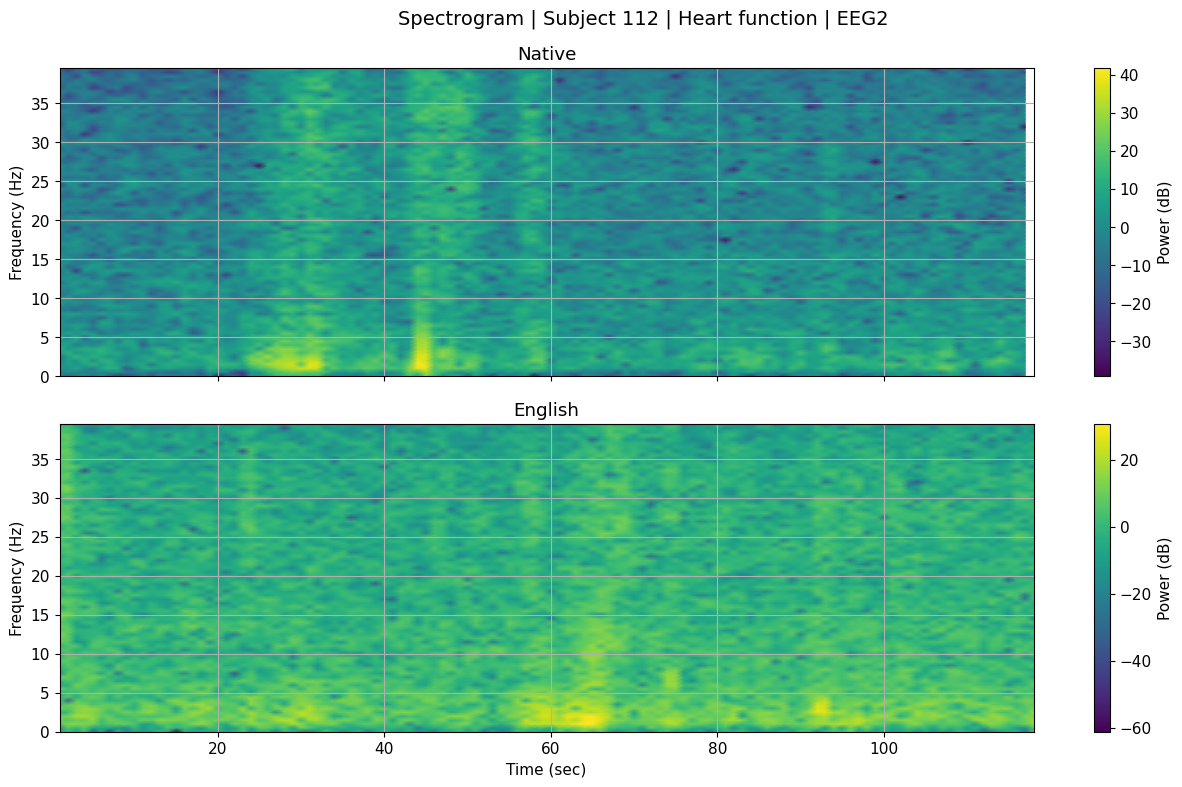

In [31]:
# This cell creates a spectrogram.
# A spectrogram shows how frequency content changes over time.
# It is a nice figure for your report because it combines time and frequency in one image.

def plot_pair_spectrogram(subject, topic_num, channel="EEG1", max_freq=40):
    native_id, english_id = get_pair_file_ids(subject, topic_num)

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    fig.suptitle(f"Spectrogram | Subject {subject} | {topic_map[topic_num]} | {channel}", fontsize=14)

    for ax, file_id, label in zip(axes, [native_id, english_id], ["Native", "English"]):
        df = recordings[file_id]["clean"]
        fs = recordings[file_id]["fs"]
        x = df[channel].to_numpy()

        f, t, sxx = signal.spectrogram(x, fs=fs, nperseg=int(fs * 2), noverlap=int(fs))
        keep = f <= max_freq

        pcm = ax.pcolormesh(t, f[keep], 10 * np.log10(sxx[keep] + 1e-12), shading="gouraud")
        ax.set_ylabel("Frequency (Hz)")
        ax.set_title(label)
        fig.colorbar(pcm, ax=ax, label="Power (dB)")

    axes[-1].set_xlabel("Time (sec)")
    plt.tight_layout()
    plt.show()

# Example
plot_pair_spectrogram(subject="112", topic_num=3, channel="EEG2")

In [32]:
# This cell gives a simple channel-by-channel table.
# This is useful if you want to say which channels show bigger differences
# between Native and English.

channel_summary = (
    bandpower_table
    .pivot_table(
        index=["subject", "topic_name", "channel", "band"],
        columns="condition",
        values="rel_power"
    )
    .reset_index()
)

channel_summary["Native_minus_English"] = channel_summary["Native"] - channel_summary["English"]
channel_summary

condition,subject,topic_name,channel,band,English,Native,Native_minus_English
0,111,Heart function,EEG1,alpha,0.044571,0.031774,-0.012796
1,111,Heart function,EEG1,beta,0.049970,0.035213,-0.014757
2,111,Heart function,EEG1,delta,0.668315,0.703318,0.035003
3,111,Heart function,EEG1,gamma,0.009148,0.005465,-0.003684
4,111,Heart function,EEG1,theta,0.187780,0.190701,0.002921
5,111,Heart function,EEG2,alpha,0.070599,0.059395,-0.011204
6,111,Heart function,EEG2,beta,0.311899,0.228147,-0.083752
7,111,Heart function,EEG2,delta,0.372706,0.479847,0.107142
8,111,Heart function,EEG2,gamma,0.112753,0.075183,-0.037571
9,111,Heart function,EEG2,theta,0.106416,0.129421,0.023005


In [33]:
# This cell saves the main tables to files.
# This is useful because later you may want to use the results in Excel,
# in a report table, or in another notebook.

recording_summary.to_csv(results_path / "recording_summary.csv", index=False)
bandpower_table.to_csv(results_path / "bandpower_table_channel_level.csv", index=False)
bandpower_summary.to_csv(results_path / "bandpower_summary_mean.csv", index=False)
channel_summary.to_csv(results_path / "channel_summary_native_minus_english.csv", index=False)
heat_matrix.to_csv(results_path / "heatmap_native_minus_english.csv")

print("Saved result tables to:", results_path)

Saved result tables to: /Users/mehdizaeifi/Desktop/5903_dataset/analysis_results


In [34]:
# This cell is optional.
# Because you only have 2 subjects and 3 topics, strong statistics are not the main point here.
# Still, this cell gives a small descriptive paired comparison across the 3 topics for each subject.
# Please present this carefully in your project and do not overclaim.

stats_rows = []

for subject in sorted(bandpower_summary["subject"].unique()):
    for band_name in bands.keys():
        temp = bandpower_summary[
            (bandpower_summary["subject"] == subject) &
            (bandpower_summary["band"] == band_name)
        ].pivot_table(index="topic_num", columns="condition", values="rel_power")

        if {"Native", "English"}.issubset(temp.columns) and len(temp) >= 2:
            diffs = temp["Native"] - temp["English"]

            try:
                stat, pval = wilcoxon(diffs)
            except:
                stat, pval = np.nan, np.nan

            stats_rows.append({
                "subject": subject,
                "band": band_name,
                "n_topics": len(diffs),
                "mean_native_minus_english": diffs.mean(),
                "median_native_minus_english": diffs.median(),
                "wilcoxon_stat": stat,
                "wilcoxon_p": pval
            })

stats_table = pd.DataFrame(stats_rows)
stats_table

,subject,band,n_topics,mean_native_minus_english,median_native_minus_english,wilcoxon_stat,wilcoxon_p
0,111,delta,3,-0.002494,0.016178,3.0,1.00
1,111,theta,3,-0.000992,-0.006046,3.0,1.00
2,111,alpha,3,-0.007542,-0.009459,1.0,0.50
3,111,beta,3,0.005020,0.006006,1.0,0.50
4,111,gamma,3,0.007076,0.008243,1.0,0.50
5,112,delta,3,0.087851,0.087023,0.0,0.25
6,112,theta,3,-0.000280,-0.008494,3.0,1.00
7,112,alpha,3,-0.006028,-0.008529,1.0,0.50
8,112,beta,3,-0.055254,-0.041991,0.0,0.25
9,112,gamma,3,-0.021463,-0.007335,0.0,0.25


In [35]:
# This cell makes a small summary sentence table.
# It helps you quickly see whether Native tended to be higher or lower than English in each band.
# This is useful for writing the discussion section in simple language.

discussion_table = (
    bandpower_summary
    .pivot_table(
        index=["subject", "topic_name", "band"],
        columns="condition",
        values="rel_power"
    )
    .reset_index()
)

discussion_table["difference"] = discussion_table["Native"] - discussion_table["English"]
discussion_table["which_is_higher"] = np.where(
    discussion_table["difference"] > 0,
    "Native higher",
    np.where(discussion_table["difference"] < 0, "English higher", "Same")
)

discussion_table

condition,subject,topic_name,band,English,Native,difference,which_is_higher
0,111,Heart function,alpha,0.066544,0.057085,-0.009459,English higher
1,111,Heart function,beta,0.129908,0.126682,-0.003226,English higher
2,111,Heart function,delta,0.567732,0.589750,0.022018,Native higher
3,111,Heart function,gamma,0.036158,0.032895,-0.003263,English higher
4,111,Heart function,theta,0.167802,0.161757,-0.006046,English higher
5,111,Probability,alpha,0.061265,0.044736,-0.016528,English higher
6,111,Probability,beta,0.085033,0.097312,0.012279,Native higher
7,111,Probability,delta,0.658349,0.674528,0.016178,Native higher
8,111,Probability,gamma,0.015032,0.031280,0.016248,Native higher
9,111,Probability,theta,0.151117,0.123805,-0.027312,English higher
